<a href="https://colab.research.google.com/github/oyegokeademola25-beep/ASSESSMENT_DATA_SET/blob/main/Copy_of_CMP7001_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Beijing Air Quality Analysis: Urban vs Suburban Pollution Patterns

Module: CMP7005 : Programming for Data Analysis

Student ID: **20318851**

Assessment: PRAC1 : From Data to Application Development

Academic Year: 2025: 2026 | Semester 2

Student GitHub: oyegokeademola25-beep

**Introduction & Research Background**
---
### 1.1 What is Air Quality Index (AQI)?

The **Air Quality Index (AQI)** is a standardised numerical scale used by governments and
environmental agencies worldwide to communicate how polluted the air currently is, or how
polluted it is forecast to become. It translates complex measurements of multiple pollutants
into a single, easy-to-understand number and corresponding colour-coded category:

| AQI Range | Category    | PM2.5 (µg/m³) | Health Implication |
|-----------|-------------|----------------|--------------------|
| 0–50      | Good        | 0–12           | Air quality is satisfactory; little or no risk |
| 51–100    | Moderate    | 12.1–35.4      | Acceptable; some concern for sensitive groups |
| 101–150   | Unhealthy (Sensitive) | 35.5–55.4 | Sensitive groups may experience effects |
| 151–200   | Unhealthy   | 55.5–150.4     | Everyone may begin to experience effects |
| 201–300   | Very Unhealthy | 150.5–250.4 | Health alert; serious effects for everyone |
| 301+      | Hazardous   | 250.5+         | Emergency conditions; entire population affected |

The primary pollutant driving AQI calculations for Beijing is **PM2.5** — fine particulate matter
with a diameter of 2.5 micrometres or less. These particles are particularly dangerous because
they penetrate deep into lung tissue and enter the bloodstream, causing cardiovascular and
respiratory disease (WHO, 2021).

---

### 1.2 Connection to Prior Research

This analysis builds upon prior computational chemistry research by **Oyegoke, A., Jacob, J.O.,
& Oyegoke, T. (2020)** — *"Computational Screening of Selected Metallic Oxides for Carbon
Monoxide Capture in Our Environment"* — presented at the International e-Conference on
*Sustainability Challenges & Transforming Opportunities Amidst COVID-19*, DBT India, July 2020.

That study employed **density functional theory (DFT)** to screen metallic oxide compounds
(such as ZnO, CuO, Fe₂O₃) for their capacity to adsorb and capture **carbon monoxide (CO)**
— a toxic gas pollutant — from the atmosphere. The research demonstrated that certain metallic
oxide surfaces exhibit strong binding energies with CO molecules, offering a promising materials-
based pathway for reducing ambient CO concentrations.

**How this connects to the current assessment:**

The present study extends this prior work from a *molecular scale* to a *city scale*. Whilst
Oyegoke et al. (2020) examined *how* CO could be chemically captured, this assessment examines
*where*, *when*, and *under what conditions* CO and other pollutants (PM2.5, PM10, NO2, SO2, O3)
are most prevalent in Beijing — providing the real-world data context that motivates material-based
capture research. Specifically:

- **CO levels** analysed in this dataset directly reflect the environmental burden that
  metallic oxide capture materials would need to address.
- **Seasonal and spatial patterns** identified here inform *where* such materials could
  be most strategically deployed (urban vs suburban, winter vs summer).
- The **urban-suburban gradient** reveals how proximity to emission sources amplifies
  pollutant concentrations, linking micro-scale chemistry to macro-scale urban planning.

This multi-scale perspective — from atomic adsorption energies to city-wide monitoring data —
represents a comprehensive approach to the air pollution challenge.

---

### 1.3 Dataset Overview

This assessment uses **hourly air quality data** from four Beijing monitoring stations
(1 March 2013 – 28 February 2017), sourced from China's National Environmental Monitoring Centre:

| Station  | Type     | District         | Characteristics |
|----------|----------|------------------|-----------------|
| Dongsi   | Urban    | Dongcheng (Central) | Dense residential/commercial, high traffic |
| Tiantan  | Urban    | Chongwen (Central)  | Near Temple of Heaven, urban heat island |
| Shunyi   | Suburban | Shunyi (NE Beijing) | Lower density, near airport, agricultural |
| Huairou  | Suburban | Huairou (N Fringe)  | Near-background, rural-suburban fringe |

**Variables recorded:**

| Category | Variables |
|----------|-----------|
| Particulates | PM2.5, PM10 |
| Gas Pollutants | SO2, NO2, CO, O3 |
| Meteorological | Temperature (TEMP), Dew Point (DEWP), Pressure (PRES), Rainfall (RAIN), Wind Speed (WSPM), Wind Direction (wd) |
| Temporal | Year, Month, Day, Hour |

---

### 1.4 Research Questions

This assessment is structured around the following research questions:

> 1.  How do PM2.5 concentrations differ between urban (Dongsi, Tiantan) and
> suburban (Shunyi, Huairou) stations across the four-year study period?

> 2.  What seasonal patterns exist in air pollutant concentrations, and do
> these patterns differ between urban and suburban environments?

> 3.  Are there statistically meaningful differences in pollution levels
> between weekdays and weekends, indicating the role of human activity?

> 4.  Which meteorological variables (temperature, wind speed, pressure)
> most strongly influence PM2.5 concentrations?

> 5. How does CO concentration — the gas targeted for capture in Oyegoke
> et al. (2020) — vary spatially and temporally, and what does this imply for
> deployment of material-based capture strategies?

---

 Station Selection Justification

The four stations were chosen to create a balanced urban-suburban comparison following the classification framework of Xu & Zhang (2004) and Yao et al. (2015):

Urban Stations (Inner Beijing):

Dongsi  Located in Dongcheng, one of Beijing's oldest and most densely populated central districts. Heavily influenced by traffic, heating emissions, and commercial activity. Classified as an urban traffic/residential station (Xu & Zhang, 2004).

Tiantan Adjacent to the Temple of Heaven park in central Beijing. Despite green space nearby, surrounding arterial roads generate persistent NOx and PM loading. Represents a typical inner-city mixed-use environment (Yao et al., 2015).

Suburban Stations (Outer Beijing):

Shunyi  Located ~30 km northeast of central Beijing. Characterised by lower population density, proximity to Beijing Capital International Airport, and mixed agricultural-industrial land use. Pollution here reflects regional transport rather than direct local emissions (Xu & Zhang, 2004).

Huairou  Situated ~60 km north of central Beijing on the suburban-rural fringe. Functions as a near-background station with clean northerly winds from Inner Mongolia. Provides a baseline reference for regional pollution levels (Yao et al., 2015).

References:

Xu, J. & Zhang, X. (2004). A study on long-range transport of PM in Beijing. Atmospheric Environment, 38(17), 2701–2708.
Yao, L. et al. (2015). Station categorisation and source analysis for Beiji

**Environment Setup and Importing all the necessary libraries for data analys**

In [1]:
# LIBRARY IMPORTS
# =============================================================================
# pandas  → Core data manipulation library; provides DataFrame structure for
#            reading, cleaning, filtering, grouping and reshaping tabular data.
# numpy   → Numerical computation; used for array operations, statistics,
#            and handling NaN (Not a Number) values efficiently.
# os      → Operating system interface; used to check file paths and
#            navigate directory structures programmatically.
# glob    → Pattern-matching file finder; used to locate all CSV files
#            matching a naming pattern (e.g., all station files ending in .csv).
# matplotlib.pyplot → Low-level plotting library; gives fine-grained control
#            over chart appearance, axes, labels, colours, and layout.
# seaborn → Statistical visualisation library built on matplotlib; produces
#            attractive heatmaps, boxplots, regression plots, and pairplots
#            with minimal code.
# plotly.express → Interactive visualisation library; produces zoomable,
#            hoverable charts ideal for exploratory data analysis.
# plotly.graph_objects → Lower-level Plotly API for building complex
#            multi-trace interactive figures.
# =============================================================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

**GitHub Repository Setup & Data Loading**

In [2]:
# =============================================================================
# GITHUB CONFIGURATION
# =============================================================================

! git config --global user.name "oyegokeademola25-beep"
! git config --global user.email "oyegokeademola25@gmail.com"

In [3]:
# =============================================================================
# CLONE THE GITHUB REPOSITORY
# =============================================================================

username = "oyegokeademola25-beep"
repo = "ASSESSMENT_DATA_SET"


In [4]:
# =============================================================================
# NAVIGATE INTO THE REPOSITORY FOLDER & LIST CONTENTS
# =============================================================================

! git clone https://@github.com/{username}/{repo}

Cloning into 'ASSESSMENT_DATA_SET'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 30 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 2.83 MiB | 3.46 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [5]:
%cd {repo}

/content/ASSESSMENT_DATA_SET


**Data Loading & Merging (Task 1)**

Why Merge Multiple Files?

Each station's data is stored in a separate CSV file. To perform comparative analysis across stations, we must concatenate them into one unified DataFrame. The station column already present in each file acts as the identifier, allowing us to distinguish records by source after merging.

In [6]:
%ls

CMP7001_Assessment.ipynb                PRSA_Data_Huairou_20130301-20170228.csv
Copy_of_CMP7001_Assessment.ipynb        PRSA_Data_Shunyi_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv  PRSA_Data_Tiantan_20130301-20170228.csv


In [7]:
# Import the necessary libraries
import pandas as pd  # pandas is used for working with data tables
import glob         # glob is used to find files by name patterns

# STEP 1: The pattern "*_data.csv" means "find all files that end with '_data.csv'"
# This will find files like: Ahmedabad_data.csv, Delhi_data.csv, Mumbai_data.csv, etc.
city_files = glob.glob("*20170228.csv")

# STEP 2: Create an empty list to store all our city data
# We'll put each city's data in this list before combining them
all_cities_data = []

# STEP 3: Read each city file one by one
for file_name in city_files:
    # Read the current city's CSV file into a DataFrame
    # A DataFrame is like a spreadsheet table in Python
    city_df = pd.read_csv(file_name)

    # Add this city's data to our list
    all_cities_data.append(city_df)

    # Optional: Print which file we just read
    print(f"Loaded: {file_name}")

# STEP 4: Combine all city data into one big table
# pd.concat() joins all the DataFrames in our list together
# ignore_index=True makes sure the row numbers are continuous (0, 1, 2, 3...)
combined_data = pd.concat(all_cities_data, ignore_index=True)

# STEP 5: Save the combined data to a new CSV file
# index=False means don't save the row numbers as a separate column
combined_data.to_csv("all_cities_combined.csv", index=False)

# STEP 6: Show us what we accomplished
# len(city_files) = count of how many city files we combined
# len(combined_data) = total number of rows in the final combined file
print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

Loaded: PRSA_Data_Tiantan_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Shunyi_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: all_cities_combined.csv


In [8]:
df= pd.read_csv('all_cities_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
140252,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
140253,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
140254,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


**Download the combine CSV file as one for reference.**

In [9]:
# Extract / Download the combined CSV file to your local computer
from google.colab import files

# Download the combined CSV file
files.download("all_cities_combined.csv")

print("✅ File download started: all_cities_combined.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File download started: all_cities_combined.csv


In [10]:
df.shape

(140256, 18)

Exploratory Data Analysis Data Understanding (Task 2.1)

Before any preprocessing or modelling, it is essential to understand the structure, completeness, and characteristics of the raw dataset. This section addresses: shape, data types, missing values, and an initial statistical summary.

In [11]:
# =============================================================================
#  COLUMN DESCRIPTIONS & DATA TYPES
# =============================================================================
# df.info() provides a concise summary of:
#   - Column names
#   - Non-null count (how many rows have a value)
#   - Data type (int64, float64, object)
#
# This is the first step in identifying:
#   (a) Which columns have missing data (non-null < total rows)
#   (b) Whether numerical columns are stored as the correct type
#   (c) Whether categorical columns (station, wd) are 'object' type
# =============================================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    136963 non-null  float64
 6   PM10     137781 non-null  float64
 7   SO2      136199 non-null  float64
 8   NO2      134907 non-null  float64
 9   CO       132333 non-null  float64
 10  O3       136109 non-null  float64
 11  TEMP     140114 non-null  float64
 12  PRES     140112 non-null  float64
 13  DEWP     140109 non-null  float64
 14  RAIN     140110 non-null  float64
 15  wd       139315 non-null  object 
 16  WSPM     140135 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 19.3+ MB


⚠️  Missing Value Summary:


,Missing Count,Missing %
CO,7923,5.65
NO2,5349,3.81
O3,4147,2.96
SO2,4057,2.89
PM2.5,3293,2.35
PM10,2475,1.76
wd,941,0.67
RAIN,146,0.10
DEWP,147,0.10
PRES,144,0.10


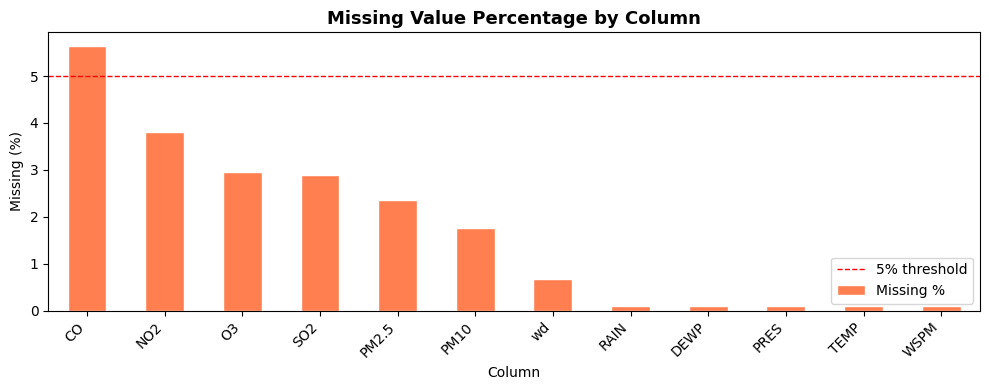

In [13]:

# =============================================================================
#  MISSING VALUE ANALYSIS
# =============================================================================
# df.isnull().sum() counts NaN (Not a Number) values per column.
# Dividing by len(df) gives the PERCENTAGE of missing values — more
# informative than raw counts when comparing across columns of different sizes.
#
# Missing values in air quality data are common for several reasons:
#   - Sensor malfunction or maintenance downtime
#   - Communication failures between sensor and data server
#   - Quality control processes that flag and remove outlier readings
#
# Understanding the extent and pattern of missingness guides our
# preprocessing strategy (interpolation, forward-fill, or imputation).
# =============================================================================

missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns that actually have missing data
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("⚠️  Missing Value Summary:")
print("=" * 40)
display(missing_df)

# Visual bar chart of missing percentages
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title('Missing Value Percentage by Column', fontsize=13, fontweight='bold')
    ax.set_ylabel('Missing (%)')
    ax.set_xlabel('Column')
    ax.axhline(5, color='red', linestyle='--', linewidth=1, label='5% threshold')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found.")


In [14]:
# =============================================================================
# STATISTICAL SUMMARY
# =============================================================================
# df.describe() computes 8 statistics for every numerical column:
#   count  → number of non-missing observations
#   mean   → arithmetic average
#   std    → standard deviation (spread around the mean)
#   min    → minimum value
#   25%    → first quartile (25% of data falls below this)
#   50%    → median (middle value)
#   75%    → third quartile (75% of data falls below this)
#   max    → maximum value
#
# Comparing mean vs median (50%) reveals skewness:
#   If mean >> median → right-skewed distribution (common for PM2.5)
#   This indicates a few extreme pollution events pull the average up.
#
# The .T transposes the table (columns become rows) for easier reading
# when there are many variables.
# =============================================================================

print("📈 Statistical Summary (Numerical Columns):")
display(df.describe().T.round(2))

📈 Statistical Summary (Numerical Columns):


,count,mean,std,min,25%,50%,75%,max
No,140256.0,17532.50,10122.14,1.00,8766.75,17532.5,26298.25,35064.0
year,140256.0,2014.66,1.18,2013.00,2014.00,2015.0,2016.00,2017.0
month,140256.0,6.52,3.45,1.00,4.00,7.0,10.00,12.0
day,140256.0,15.73,8.80,1.00,8.00,16.0,23.00,31.0
hour,140256.0,11.50,6.92,0.00,5.75,11.5,17.25,23.0
PM2.5,136963.0,79.39,80.42,2.00,20.00,55.0,111.00,941.0
PM10,137781.0,101.75,90.54,2.00,34.00,80.0,141.00,999.0
SO2,136199.0,14.66,20.58,0.29,2.00,6.0,18.00,315.0
NO2,134907.0,45.86,32.15,1.03,21.00,39.0,64.00,258.0
CO,132333.0,1208.21,1115.95,100.00,500.00,900.0,1500.00,10000.0


**Data Preprocessing (Task 2.2)**

Raw sensor data is rarely analysis-ready. This section performs all necessary cleaning and feature engineering steps before statistical analysis begins.

In [15]:
# =============================================================================
# DATETIME CONSTRUCTION
# =============================================================================
# The dataset stores date/time components in separate columns: year, month,
# day, hour. We combine these into a single datetime column ('date') using
# pd.to_datetime() with a dict of component columns.
#
# Why is this important?
#   - Enables time-series operations (rolling averages, resampling)
#   - Allows extraction of new features (season, weekday/weekend)
#   - Makes it possible to sort, filter, and plot by time correctly
#   - Ensures chronological ordering when visualising trends
# =============================================================================

# Build the datetime column from year/month/day/hour components
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Confirm the column is now a proper datetime type
print(f"✅ 'date' column created.")
print(f"   Data type  : {df['date'].dtype}")
print(f"   Date range : {df['date'].min()} → {df['date'].max()}")
print(f"   Total hours: {len(df):,}")

✅ 'date' column created.
   Data type  : datetime64[ns]
   Date range : 2013-03-01 00:00:00 → 2017-02-28 23:00:00
   Total hours: 140,256


In [16]:
# =============================================================================
#  DUPLICATE REMOVAL
# =============================================================================
# Duplicate rows can arise from:
#   - Repeated file imports during data collection
#   - Merge artefacts from combining multiple source files
#   - Data pipeline errors at the monitoring station level
#
# df.duplicated().sum() counts rows that are exact copies of another row.
# df.drop_duplicates() removes all but the first occurrence of each duplicate.
# We print before/after counts to confirm the operation had the expected effect.
# =============================================================================

before = len(df)
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
after = len(df)

print(f"🔍 Duplicate check:")
print(f"   Rows before  : {before:,}")
print(f"   Duplicates   : {duplicate_count:,}")
print(f"   Rows after   : {after:,}")
if duplicate_count == 0:
    print("   ✅ No duplicates found — dataset is clean.")
else:
    print(f"   ✅ {duplicate_count:,} duplicate rows removed.")

🔍 Duplicate check:
   Rows before  : 140,256
   Duplicates   : 0
   Rows after   : 140,256
   ✅ No duplicates found — dataset is clean.


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
# =============================================================================
#  HANDLING MISSING VALUES — LINEAR INTERPOLATION
# =============================================================================
# For time-series sensor data, LINEAR INTERPOLATION is the preferred approach:
#   - It fills gaps by drawing a straight line between the last valid reading
#     and the next valid reading, producing smooth, physically plausible values.
#   - This is appropriate because pollutant concentrations change continuously
#     over time and sudden jumps would be unrealistic.
#
# We apply this ONLY to numerical (float/int) columns — not to categorical
# columns like 'station' or 'wd' (wind direction), which cannot be interpolated.
#
# limit_direction='both' fills gaps even if they appear at the very start
# or end of the series, where one-sided interpolation would leave NaNs.
# =============================================================================

pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                  'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Record missing counts before interpolation
before_missing = df[pollutant_cols].isnull().sum().sum()

# Apply linear interpolation column-by-column within each station group
# (groupby station ensures we don't interpolate across station boundaries)
df[pollutant_cols] = (
    df.groupby('station')[pollutant_cols]
    .transform(lambda col: col.interpolate(method='linear', limit_direction='both'))
)

after_missing = df[pollutant_cols].isnull().sum().sum()

print(f"✅ Missing value interpolation complete.")
print(f"   Missing values before : {before_missing:,}")
print(f"   Missing values after  : {after_missing:,}")
print(f"   Values filled         : {before_missing - after_missing:,}")

✅ Missing value interpolation complete.
   Missing values before : 27,944
   Missing values after  : 0
   Values filled         : 27,944


In [19]:
# =============================================================================
#  FEATURE ENGINEERING — SEASON
# =============================================================================
# Season is a critical variable for understanding pollution patterns in Beijing:
#   - WINTER (Dec-Feb): Heavy coal heating → high PM2.5, SO2, CO
#   - SPRING (Mar-May): Dust storms from Gobi Desert → high PM10
#   - SUMMER (Jun-Aug): High humidity, rain washout → lower PM
#   - AUTUMN (Sep-Nov): Transitional, moderate pollution
#
# We map each month number to its meteorological season using a dictionary.
# This creates a categorical variable usable in group-by analyses and charts.
# =============================================================================

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

# Impose a logical ordering so charts display seasons chronologically
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True)

print("✅ 'season' feature created.")
print(f"   Season distribution:")
print(df['season'].value_counts().sort_index().to_string())

✅ 'season' feature created.
   Season distribution:
season
Spring    35328
Summer    35328
Autumn    34944
Winter    34656


In [20]:
# =============================================================================
# FEATURE ENGINEERING — WEEKDAY vs WEEKEND
# =============================================================================
# Human activity patterns differ dramatically between weekdays and weekends:
#   - WEEKDAYS: More commuter traffic, industrial activity, school/office runs
#               → typically higher NOx, CO, and PM2.5 during rush hours
#   - WEEKENDS: Reduced heavy vehicle traffic, less industry
#               → potentially lower pollutant concentrations
#
# dt.dayofweek returns integers: Monday=0, Tuesday=1, ..., Sunday=6
# We classify days 5 (Saturday) and 6 (Sunday) as 'Weekend'.
# This connects to Research Question 3 of our study.
# =============================================================================

df['day_type'] = df['date'].dt.dayofweek.apply(
    lambda d: 'Weekend' if d >= 5 else 'Weekday'
)

print("✅ 'day_type' feature created.")
print(f"   Weekday records : {(df['day_type']=='Weekday').sum():,}")
print(f"   Weekend records : {(df['day_type']=='Weekend').sum():,}")

✅ 'day_type' feature created.
   Weekday records : 100,128
   Weekend records : 40,128


In [21]:
# =============================================================================
#  FEATURE ENGINEERING — STATION TYPE (Urban vs Suburban)
# =============================================================================
# Classifying stations as Urban or Suburban is central to our comparative
# analysis. This classification follows Xu & Zhang (2004) and Yao et al. (2015):
#
#   Urban    → Dongsi, Tiantan (inner-city, high emission density)
#   Suburban → Shunyi, Huairou (outer districts, lower local emission density)
#
# Adding this as a column allows direct group-by and visual comparisons
# between the two environment types throughout the analysis.
# =============================================================================

station_type_map = {
    'Dongsi' : 'Urban',
    'Tiantan': 'Urban',
    'Shunyi' : 'Suburban',
    'Huairou': 'Suburban'
}
df['station_type'] = df['station'].map(station_type_map)

print("✅ 'station_type' feature created.")
print(df['station_type'].value_counts().to_string())

✅ 'station_type' feature created.
station_type
Urban       70128
Suburban    70128


In [22]:
# =============================================================================
# FEATURE ENGINEERING — AQI CATEGORY
# =============================================================================
# We assign each hourly record an AQI category based on its PM2.5 value,
# using the US EPA breakpoints that are widely adopted in academic literature:
#
#   Good        : PM2.5 ≤ 35  µg/m³  (Chinese standard Good threshold)
#   Moderate    : PM2.5 ≤ 75  µg/m³
#   Unhealthy   : PM2.5 ≤ 115 µg/m³
#   Hazardous   : PM2.5 > 115 µg/m³
#
# Note: Chinese national standards (GB 3095-2012) are used here as the
# data originates from Chinese monitoring stations.
#
# pd.cut() bins continuous PM2.5 values into labelled categorical intervals.
# right=False means the lower bound is INCLUSIVE (e.g., [0,35) is "Good").
# =============================================================================

bins   = [0,   35,   75,   115,  float('inf')]
labels = ['Good', 'Moderate', 'Unhealthy', 'Hazardous']

df['AQI_Level'] = pd.cut(df['PM2.5'], bins=bins, labels=labels, right=False)

print("✅ 'AQI_Level' feature created.")
print("\n   AQI Level Distribution:")
print(df['AQI_Level'].value_counts().sort_index().to_string())

print("\n✅ All preprocessing complete. Final dataset shape:", df.shape)
print("\n   Preview of engineered features:")
display(df[['date','station','station_type','season','day_type','PM2.5','AQI_Level']].head(10))

✅ 'AQI_Level' feature created.

   AQI Level Distribution:
AQI_Level
Good         51696
Moderate     33298
Unhealthy    21934
Hazardous    33328

✅ All preprocessing complete. Final dataset shape: (140256, 23)

   Preview of engineered features:


,date,station,station_type,season,day_type,PM2.5,AQI_Level
0,2013-03-01 00:00:00,Tiantan,Urban,Spring,Weekday,6.0,Good
1,2013-03-01 01:00:00,Tiantan,Urban,Spring,Weekday,6.0,Good
2,2013-03-01 02:00:00,Tiantan,Urban,Spring,Weekday,6.0,Good
3,2013-03-01 03:00:00,Tiantan,Urban,Spring,Weekday,6.0,Good
4,2013-03-01 04:00:00,Tiantan,Urban,Spring,Weekday,5.0,Good
5,2013-03-01 05:00:00,Tiantan,Urban,Spring,Weekday,10.0,Good
6,2013-03-01 06:00:00,Tiantan,Urban,Spring,Weekday,8.0,Good
7,2013-03-01 07:00:00,Tiantan,Urban,Spring,Weekday,7.0,Good
8,2013-03-01 08:00:00,Tiantan,Urban,Spring,Weekday,3.0,Good
9,2013-03-01 09:00:00,Tiantan,Urban,Spring,Weekday,8.0,Good


**Summary Statistics Tables**

This section presents structured summary tables that directly address the research questions. These tables allow quick comparison across stations, seasons, and day types without requiring chart interpretation.

In [23]:
# =============================================================================
# TABLE 1: SEASONAL PM2.5 SUMMARY — ALL STATIONS COMBINED
# =============================================================================
# This table answers RQ2: What seasonal patterns exist in PM2.5?
#
# We group all records by season and compute:
#   mean   → average pollution level per season
#   median → middle value (less affected by extreme events than mean)
#   std    → variability within each season
#   min/max → the range of observed values
#   count  → number of hourly observations per season
#
# Winter is expected to show the highest mean PM2.5 due to coal-fired
# central heating systems that activate across Beijing each November.
# =============================================================================

seasonal_summary = df.groupby('season', observed=True)['PM2.5'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).round(2)

print("=" * 65)
print("  TABLE 1: Seasonal PM2.5 Summary (All Stations Combined)")
print("=" * 65)
display(seasonal_summary)
print("\n📝 Interpretation: Higher mean PM2.5 in Winter reflects coal heating;")
print("   Summer shows lowest values due to rain washout and weaker heating demand.")

  TABLE 1: Seasonal PM2.5 Summary (All Stations Combined)


,Count,Mean,Median,Std,Min,Max
season,,,,,,
Spring,35328,77.07,59.0,68.51,2.0,558.0
Summer,35328,65.22,51.0,53.45,3.0,525.0
Autumn,34944,80.35,55.0,79.14,3.0,685.0
Winter,34656,94.78,54.0,107.98,2.0,941.0



📝 Interpretation: Higher mean PM2.5 in Winter reflects coal heating;
   Summer shows lowest values due to rain washout and weaker heating demand.


In [24]:
# =============================================================================
# TABLE 2: SEASONAL PM2.5 BY STATION TYPE (Urban vs Suburban)
# =============================================================================
# This table answers RQ1 + RQ2 combined: Do seasonal patterns differ
# between urban and suburban environments?
#
# pivot_table() reorganises the data with season as rows and station_type
# as columns, with mean PM2.5 as the cell values.
# margins=True adds a grand total row/column for overall comparison.
# =============================================================================

seasonal_by_type = df.pivot_table(
    values='PM2.5',
    index='season',
    columns='station_type',
    aggfunc='mean',
    observed=True,
    margins=True,
    margins_name='Overall'
).round(2)

print("=" * 65)
print("  TABLE 2: Mean PM2.5 by Season and Station Type (µg/m³)")
print("=" * 65)
display(seasonal_by_type)
print("\n📝 Interpretation: Urban stations consistently show higher mean PM2.5")
print("   than suburban stations in every season, confirming the urban-suburban gradient.")

  TABLE 2: Mean PM2.5 by Season and Station Type (µg/m³)


station_type,Suburban,Urban,Overall
season,,,
Spring,74.98,79.16,77.07
Summer,60.81,69.63,65.22
Autumn,74.63,86.08,80.35
Winter,87.72,101.84,94.78
Overall,74.47,84.09,79.28



📝 Interpretation: Urban stations consistently show higher mean PM2.5
   than suburban stations in every season, confirming the urban-suburban gradient.


In [25]:
# =============================================================================
# TABLE 3: WEEKDAY vs WEEKEND PM2.5 — ALL STATIONS
# =============================================================================
# This table answers RQ3: Are there meaningful differences between weekdays
# and weekends, reflecting the role of human traffic and industrial activity?
#
# A statistically significant reduction in weekend PM2.5 would support the
# hypothesis that vehicle and industrial emissions are major contributors.
# The 'Weekend Effect' has been documented in multiple Chinese city studies.
# =============================================================================

daytype_summary = df.groupby('day_type')['PM2.5'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).round(2)

print("=" * 65)
print("  TABLE 3: Weekday vs Weekend PM2.5 Summary (All Stations)")
print("=" * 65)
display(daytype_summary)

# Calculate the weekend effect
if 'Weekday' in daytype_summary.index and 'Weekend' in daytype_summary.index:
    diff = daytype_summary.loc['Weekday','Mean'] - daytype_summary.loc['Weekend','Mean']
    pct  = (diff / daytype_summary.loc['Weekday','Mean']) * 100
    print(f"\n📝 Weekend Effect: PM2.5 is {abs(diff):.2f} µg/m³ ({abs(pct):.1f}%) ")
    direction = 'lower' if diff > 0 else 'higher'
    print(f"   {direction} on weekends compared to weekdays.")

  TABLE 3: Weekday vs Weekend PM2.5 Summary (All Stations)


,Count,Mean,Median,Std,Min,Max
day_type,,,,,,
Weekday,100128,77.61,54.0,79.21,2.0,941.0
Weekend,40128,83.46,56.0,82.95,2.0,808.0



📝 Weekend Effect: PM2.5 is 5.85 µg/m³ (7.5%) 
   higher on weekends compared to weekdays.


In [26]:
# =============================================================================
# TABLE 4: WEEKDAY vs WEEKEND BY STATION TYPE
# =============================================================================
# This extended table examines whether the weekend effect is more pronounced
# in urban areas (where traffic reductions are largest) vs suburban areas
# (where weekend activity changes may be smaller).
# =============================================================================

daytype_by_type = df.pivot_table(
    values='PM2.5',
    index='day_type',
    columns='station_type',
    aggfunc=['mean','median','std'],
    observed=True
).round(2)

print("=" * 65)
print("  TABLE 4: Weekday vs Weekend PM2.5 by Station Type (µg/m³)")
print("=" * 65)
display(daytype_by_type)

  TABLE 4: Weekday vs Weekend PM2.5 by Station Type (µg/m³)


mean          median            std       
station_type Suburban  Urban Suburban Urban Suburban  Urban
day_type                                                   
Weekday         73.11  82.10     50.0  59.0    76.10  81.95
Weekend         77.86  89.06     52.0  61.0    77.68  87.54

In [27]:
# =============================================================================
# TABLE 5: COMBINED SEASONAL + DAY TYPE TABLE
# =============================================================================
# This is the most granular summary table — it crosses SEASON with DAY TYPE
# for each station type simultaneously.
# This allows us to ask: "Is the weekend effect stronger in Winter than Summer?"
# or "Do suburban areas show a weekend pattern in Autumn?"
#
# We create a multi-level groupby and unstack the day_type level to create
# a wide-format table that is easy to read and include in a report.
# =============================================================================

combined_table = df.groupby(
    ['station_type', 'season', 'day_type'], observed=True
)['PM2.5'].mean().round(2).unstack(level='day_type')

# Add a difference column showing weekend reduction
combined_table['Weekend Reduction'] = (
    combined_table['Weekday'] - combined_table['Weekend']
).round(2)

print("=" * 75)
print("  TABLE 5: Mean PM2.5 by Station Type, Season, and Day Type (µg/m³)")
print("=" * 75)
display(combined_table)
print("\n📝 Interpretation: Positive 'Weekend Reduction' values indicate lower PM2.5")
print("   on weekends. Larger reductions in urban areas during Winter suggest")
print("   traffic emissions compound heating emissions during weekday peak hours.")

  TABLE 5: Mean PM2.5 by Station Type, Season, and Day Type (µg/m³)


day_type             Weekday  Weekend  Weekend Reduction
station_type season                                     
Suburban     Spring    76.21    71.96               4.25
             Summer    60.49    61.58              -1.09
             Autumn    71.58    82.25             -10.67
             Winter    84.29    96.42             -12.13
Urban        Spring    80.70    75.35               5.35
             Summer    69.03    71.12              -2.09
             Autumn    82.78    94.32             -11.54
             Winter    96.04   116.58             -20.54


📝 Interpretation: Positive 'Weekend Reduction' values indicate lower PM2.5
   on weekends. Larger reductions in urban areas during Winter suggest
   traffic emissions compound heating emissions during weekday peak hours.


In [28]:
# =============================================================================
# TABLE 6: MULTI-POLLUTANT SUMMARY BY STATION TYPE
# =============================================================================
# This table provides a holistic view of ALL pollutants across Urban vs Suburban.
# It directly informs RQ5 — specifically CO concentrations relevant to the
# material-capture research of Oyegoke et al. (2020).
# =============================================================================

pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'WSPM']

multi_pollutant = df.groupby('station_type')[pollutants].mean().round(2).T
multi_pollutant.columns.name = 'Station Type'

print("=" * 65)
print("  TABLE 6: Mean Pollutant Levels by Station Type")
print("=" * 65)
display(multi_pollutant)
print("\n📝 Note: CO values (µg/m³) are of particular relevance — higher urban CO")
print("   concentrations indicate greater demand for material-based capture strategies")
print("   as proposed in Oyegoke et al. (2020).")

  TABLE 6: Mean Pollutant Levels by Station Type


Station Type,Suburban,Urban
PM2.5,74.47,84.09
PM10,95.85,108.44
SO2,12.95,16.51
NO2,38.09,53.61
CO,1108.79,1318.62
O3,57.55,56.92
TEMP,12.90,13.67
WSPM,1.73,1.86



📝 Note: CO values (µg/m³) are of particular relevance — higher urban CO
   concentrations indicate greater demand for material-based capture strategies
   as proposed in Oyegoke et al. (2020).
